# 16 - Light Rail and Minor Modes

The national graph is dominated by regular bus service, so the small modes barely affect its aggregate statistics. Here we separate four of those layers and analyze each on its own:

| `route_type` | Label we use | What it represents in this feed |
|---|---|---|
| 0 | tram/light rail | Jerusalem and Tel Aviv light-rail services |
| 5 | cable tram | the Carmelit and Haifa cable-car service |
| 8 | trolleybus | shared-taxi services using this GTFS code |
| 715 | demand/other bus | rural demand-responsive services |

Heavy rail is outside this notebook because we analyze it separately. Our question here is: **are the minor modes just small versions of the bus graph, or do their corridor shapes and concentrated service create a different kind of criticality?**

We build one graph per mode from its own trips, measure service intensity, quantify duplicate platform IDs, classify component shapes, calculate exact centrality, and remove every station one at a time to measure damage. These graphs have at most a few hundred nodes, so we can use exact betweenness instead of sampling.

The required input is the cleaned station table from notebook 01 plus the raw route, trip, agency, and stop-time files. Optional outputs from notebooks 02 and 14 add consistency checks. We save all tables, graphs, summaries, and figures under `outputs/nb/16_lightrail_and_minor_modes/`.

## 1. Initialize the working environment

We locate the repository root, switch into it, and define the GTFS and output paths. The same helper makes the notebook runnable in Colab and installs only missing packages. Everything below assumes this cell has created the shared output root.

In [ ]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

## 2. Load libraries and define the minor modes

We import the graph, data, plotting, spatial, and serialization tools, create this stage's folders, and list the four route types we want to analyze. `PROGRESS_EVERY` only controls messages during the 15.7-million-row scan. Everything after that scan runs on very small graphs.

We leave `EXACT_BETWEENNESS` enabled because the largest layer here has only 153 nodes and 194 edges. Sampling would save almost no time and would add avoidable uncertainty. The remaining constants control plot resolution, labels, and displayed rankings rather than the underlying measurements.

In [2]:
# --- Libraries, stage folders and cost knobs ------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn')

import csv, json, pickle, time
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
csv.field_size_limit(10_000_000)   # a few rows of stop_times.txt are unusually long

STAGE = OUT / '16_lightrail_and_minor_modes'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Cost knobs and mode vocabulary --------------------------------------
MINOR_ROUTE_TYPES = (0, 5, 8, 715)     # tram/light rail, cable tram, trolleybus, demand-responsive
ALL_ROUTE_TYPES = (0, 2, 3, 5, 8, 715)  # used only for the service-intensity baseline
MODE_LABELS = {0: 'tram/light rail', 2: 'rail', 3: 'bus',
               5: 'cable tram', 8: 'trolleybus', 715: 'demand/other bus'}
MODE_SLUGS = {0: 'lightrail', 5: 'cabletram', 8: 'trolleybus', 715: 'demand'}
MODE_COLORS = {0: '#dc2626', 2: '#0f766e', 3: '#94a3b8',
               5: '#0891b2', 8: '#7c3aed', 715: '#ca8a04'}

PROGRESS_EVERY = 2_000_000       # progress print interval for the streaming pass
EXACT_BETWEENNESS = True         # exact Brandes O(n*m) - trivial at this graph size
FIG_DPI = 150                    # figure resolution
TOP_N = 20                       # rows shown in top-N tables
MAX_LABELLED_STATIONS = 80       # safety cap on the labelled light-rail map

print('stage output folder :', STAGE)
print('modes analysed      :', [f'{rt} = {MODE_LABELS[rt]}' for rt in MINOR_ROUTE_TYPES])

stage output folder : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\16_lightrail_and_minor_modes
modes analysed      : ['0 = tram/light rail', '5 = cable tram', '8 = trolleybus', '715 = demand/other bus']


## 3. Prepare Hebrew station labels

These graphs are small enough that we can label individual stations, so correct Hebrew rendering matters. We select a font with the needed glyphs. In this Matplotlib environment raw Hebrew already appears in the right direction, so the helper does not reorder the text.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Locate the station table and optional comparison files

We find stage folders by their numeric prefixes. `stops_clean.csv` from notebook 01 is required because it supplies station names, coordinates, region, and metro labels. The notebook 02 network tables and notebook 14 mode inventory are loaded only if present and are used for checks later.

The helper raises a clear error for the required station file and returns `None` for an optional artifact. This keeps the core minor-mode analysis independent of those checks while still making missing data obvious.

In [4]:
# --- Resolve earlier stages by two-digit prefix ---------------------------
def stage_dir(prefix):
    """Return the output folder whose name starts with `prefix` (e.g. '02'), or None."""
    matches = sorted(p for p in OUT.glob(prefix + '*') if p.is_dir())
    return matches[0] if matches else None


def find_artifact(prefix, filename, notebook_hint, required=True):
    """Locate `filename` inside the stage folder `prefix*`; explain how to produce it."""
    sd = stage_dir(prefix)
    if sd is not None:
        direct = sd / filename
        if direct.exists():
            return direct
        matches = sorted(sd.rglob(filename))
        if matches:
            return matches[0]
    if required:
        raise FileNotFoundError(
            f"{filename} was not found under {OUT / (prefix + '*')} - "
            f"run notebook {notebook_hint} first; it writes {filename}."
        )
    return None


stops_path = find_artifact('01', 'stops_clean.csv', '01_data_preparation')
stops_df = pd.read_csv(stops_path, dtype=str, keep_default_na=False, encoding='utf-8-sig')


def _to_float(x):
    """Coordinates arrive as strings and may be blank; return None instead of raising."""
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if np.isfinite(v) else None


ATTR = {
    r['stop_id']: {
        'stop_name': r.get('stop_name', '') or '',
        'lat': _to_float(r.get('stop_lat')),
        'lon': _to_float(r.get('stop_lon')),
        'region': r.get('region', '') or '',
        'metro': r.get('metro', '') or '',
        'parent_station': r.get('parent_station', '') or '',
    }
    for r in stops_df.to_dict('records')
}
DEFAULT_ATTR = {'stop_name': '', 'lat': None, 'lon': None,
                'region': '', 'metro': '', 'parent_station': ''}

# Optional cross-check inputs.
nodes_path = find_artifact('02', 'nodes.csv', '02_graph_construction', required=False)
edges_path = find_artifact('02', 'edges.csv', '02_graph_construction', required=False)
inventory14_path = find_artifact('14', 'mode_inventory.csv', '14_mode_inventory', required=False)

print(f'stop attributes : {len(ATTR):,} stops  <-  {stops_path}')
print('optional nodes.csv        :', nodes_path)
print('optional edges.csv        :', edges_path)
print('optional mode_inventory   :', inventory14_path)

stop attributes : 34,932 stops  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\01_data_preparation\tables\stops_clean.csv
optional nodes.csv        : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\nodes.csv
optional edges.csv        : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\edges.csv
optional mode_inventory   : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\tables\mode_inventory.csv


## 5. Assign every trip to a route type and operator

We join `trips.txt` to `routes.txt` because stop-time rows know only `trip_id`, while mode and agency live on the route. The result becomes a dictionary from trip ID to route type, which makes the streaming loop a constant-time lookup.

We also join agency names to the route table. That is how we verify what the unusual codes mean in this feed: the code-8 routes belong to shared-taxi operators, so we keep the raw GTFS label in the data but interpret the layer as taxi-coded rather than a physical trolleybus network.

In [5]:
# --- routes.txt / trips.txt / agency.txt ----------------------------------
for p in (DATA / 'routes.txt', DATA / 'trips.txt', DATA / 'agency.txt'):
    if not p.exists():
        raise FileNotFoundError(f'{p} is missing - the GTFS feed must be present under {DATA}.')

agency_name = {}
with open(DATA / 'agency.txt', encoding='utf-8-sig', newline='') as f:
    for a in csv.DictReader(f):
        agency_name[a.get('agency_id', '')] = a.get('agency_name', '')

route_type_of, route_meta = {}, {}
with open(DATA / 'routes.txt', encoding='utf-8-sig', newline='') as f:
    for r in csv.DictReader(f):
        try:
            rt = int(r['route_type'])
        except (TypeError, ValueError, KeyError):
            continue
        rid = r['route_id']
        route_type_of[rid] = rt
        route_meta[rid] = {
            'route_type': rt,
            'route_short_name': r.get('route_short_name', '') or '',
            'route_long_name': r.get('route_long_name', '') or '',
            'agency': agency_name.get(r.get('agency_id', ''), r.get('agency_id', '')),
        }

trip_mode, trip_route = {}, {}
trips_per_mode, trips_by_route = Counter(), Counter()
routes_with_trips = defaultdict(set)
with open(DATA / 'trips.txt', encoding='utf-8-sig', newline='') as f:
    for t in csv.DictReader(f):
        rt = route_type_of.get(t.get('route_id'))
        if rt is None:
            continue
        tid = t['trip_id']
        trip_mode[tid] = rt
        trips_per_mode[rt] += 1
        trips_by_route[t['route_id']] += 1
        routes_with_trips[rt].add(t['route_id'])
        if rt in MINOR_ROUTE_TYPES:
            trip_route[tid] = t['route_id']

routes_per_mode = Counter(route_type_of.values())
inventory = pd.DataFrame([
    {'route_type': rt,
     'mode_label': MODE_LABELS.get(rt, f'route_type {rt}'),
     'routes': routes_per_mode[rt],
     'routes_with_trips': len(routes_with_trips[rt]),
     'trips': trips_per_mode[rt],
     'trips_per_route': round(trips_per_mode[rt] / max(routes_per_mode[rt], 1), 1),
     'is_minor_mode': rt in MINOR_ROUTE_TYPES}
    for rt in sorted(routes_per_mode)
]).sort_values('trips', ascending=False).reset_index(drop=True)

print(f'routes: {len(route_type_of):,} | trips: {len(trip_mode):,}')
print(f'minor-mode trips to be streamed in detail: {sum(trips_per_mode[rt] for rt in MINOR_ROUTE_TYPES):,}')
inventory

routes: 7,792 | trips: 420,133
minor-mode trips to be streamed in detail: 6,401


,route_type,mode_label,routes,routes_with_trips,trips,trips_per_route,is_minor_mode
0,3,bus,6796,6796,412544,60.7,False
1,5,cable tram,4,4,3006,751.5,True
2,0,tram/light rail,8,8,2890,361.2,True
3,2,rail,962,962,1188,1.2,False
4,715,demand/other bus,14,14,458,32.7,True
5,8,trolleybus,8,8,47,5.9,True


### 5a. Inspect the routes assigned to the minor modes

There are only 34 route records across the four selected codes, so we print all of them with operator and trip count. Recognizable line and operator names are a quick check that the trip-to-mode join worked before we scan millions of stop-time rows.

If notebook 14's inventory exists, we compare its per-mode route and trip totals with the counts calculated here. We treat a mismatch as a data or join problem; we do not combine two inconsistent counts.

In [6]:
# --- Every minor-mode route, with operator and trip count -----------------
minor_routes = pd.DataFrame([
    {'route_type': meta['route_type'],
     'mode_label': MODE_LABELS.get(meta['route_type'], ''),
     'route_id': rid,
     'agency': meta['agency'],
     'route_short_name': meta['route_short_name'],
     'route_long_name': meta['route_long_name'],
     'trips': trips_by_route.get(rid, 0)}
    for rid, meta in route_meta.items() if meta['route_type'] in MINOR_ROUTE_TYPES
]).sort_values(['route_type', 'trips'], ascending=[True, False]).reset_index(drop=True)
minor_routes.to_csv(TABLES / 'minor_mode_routes.csv', index=False, encoding='utf-8-sig')

print('agencies per minor mode:')
for rt in MINOR_ROUTE_TYPES:
    ags = sorted(set(minor_routes.loc[minor_routes['route_type'] == rt, 'agency']))
    print(f'  {rt:>3} {MODE_LABELS[rt]:<18} {len(ags)} operator(s): {", ".join(ags)}')

# Optional consistency check against notebook 14.
if inventory14_path is not None:
    inv14 = pd.read_csv(inventory14_path, encoding='utf-8-sig')
    merged = inventory.merge(inv14, on='route_type', how='inner', suffixes=('_here', '_nb14'))
    if len(merged):
        bad = merged[(merged['routes_here'] != merged['routes_nb14'])
                     | (merged['trips_here'] != merged['trips_nb14'])]
        print('\nCross-check vs notebook 14 mode_inventory.csv:',
              'consistent' if bad.empty else 'MISMATCH - investigate')
        if not bad.empty:
            display(bad)
else:
    print('\nnotebook 14 output not present - inventory cross-check skipped (not an error).')

minor_routes

agencies per minor mode:
    0 tram/light rail    2 operator(s): כפיר, תבל
    5 cable tram         2 operator(s): כבל אקספרס, כרמלית
    8 trolleybus         3 operator(s): אודליה מוניות בעמ, מוניות מטרו קו, מוניות רב קווית 4-5
  715 demand/other bus   3 operator(s): מועצה אזורית אילות, קווים, תנופה

Cross-check vs notebook 14 mode_inventory.csv: consistent


,route_type,mode_label,route_id,agency,route_short_name,route_long_name,trips
0,0,tram/light rail,34447,תבל,1,תחנה מרכזית פתח תקווה-פתח תקווה<->הקוממיות-בת ...,608
1,0,tram/light rail,34448,תבל,1,הקוממיות-בת ים<->תחנה מרכזית פתח תקווה-פתח תקו...,607
2,0,tram/light rail,34449,תבל,3,קרית אריה-פתח תקווה<->אליפלט-תל אביב יפו-10,582
3,0,tram/light rail,34450,תבל,3,אליפלט-תל אביב יפו<->קרית אריה-פתח תקווה-20,580
4,0,tram/light rail,10746,כפיר,1,הדסה עין כרם-ירושלים<->נווה יעקב - צפון-ירושלי...,232
5,0,tram/light rail,10747,כפיר,1,נווה יעקב - צפון-ירושלים<->הדסה עין כרם-ירושלי...,232
6,0,tram/light rail,34446,תבל,2,הקוממיות-בת ים<->קרית אריה-פתח תקווה-20,31
7,0,tram/light rail,29438,כפיר,1,גבעת המבתר-ירושלים<->הדסה עין כרם-ירושלים-24,18
8,5,cable tram,29602,כבל אקספרס,10,מרכזית המפרץ-חיפה<->אוניברסיטת חיפה-חיפה-10,1201
9,5,cable tram,29603,כבל אקספרס,10,אוניברסיטת חיפה-חיפה<->מרכזית המפרץ-חיפה-20,1201


## 6. Make sure `stop_times.txt` is available

The actual stop sequences are in the 816 MB `stop_times.txt` file. We download it only when missing, then use the local path for the rest of the notebook. This keeps the large file outside the small tracked project data while still making the analysis reproducible.

In [7]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## 7. Parse GTFS service-day times correctly

GTFS hours can exceed 23. A departure at `25:04:00` belongs to the same service day and must sort after `23:50:00`; parsing it as a normal wall clock either fails or wraps it to the wrong side of midnight.

We therefore convert `HH:MM:SS` directly to seconds with no modulo operation. The function returns `None` for missing or malformed values and allows the hour field to keep increasing. The assertions test normal time, after-midnight time, blanks, and malformed input before we rely on it for service spans and headways.

In [8]:
# --- GTFS clock -> seconds since service midnight -------------------------
def gtfs_seconds(value):
    """Parse a GTFS 'HH:MM:SS' field into seconds since service midnight.

    Hours >= 24 are legal in GTFS ('25:30:00' is 01:30 on the next calendar day) and
    are preserved as > 86400 seconds. datetime/strptime must never be used here - it
    raises on hour >= 24, which is ~1.1% of the rows in this feed.
    """
    if not value:
        return None
    parts = value.strip().split(':')
    if len(parts) != 3:
        return None
    try:
        h, m, s = int(parts[0]), int(parts[1]), int(parts[2])
    except ValueError:
        return None
    return h * 3600 + m * 60 + s


def hhmm(sec):
    """Format seconds-since-service-midnight as HH:MM, keeping hours >= 24 visible."""
    if sec is None:
        return ''
    return f'{int(sec) // 3600:02d}:{int(sec) % 3600 // 60:02d}'


assert gtfs_seconds('05:10:00') == 5 * 3600 + 10 * 60
assert gtfs_seconds('25:30:00') == 25 * 3600 + 30 * 60 == 91800
assert gtfs_seconds('24:00:00') == 86400
assert gtfs_seconds('') is None and gtfs_seconds('not a time') is None
assert hhmm(91800) == '25:30'
print('gtfs_seconds OK -  "25:30:00" ->', gtfs_seconds('25:30:00'),
      'seconds since service midnight, formatted as', hhmm(gtfs_seconds('25:30:00')))

gtfs_seconds OK -  "25:30:00" -> 91800 seconds since service midnight, formatted as 25:30


## 8. Stream calls for every mode and retain minor-mode trip sequences

We read `stop_times.txt` once. For all six route types we count station calls and unique stations so we can compare service intensity without another pass. For the four minor modes we keep each trip's `(stop_sequence, stop_id, departure_seconds)` rows in memory. They make up only a small fraction of the feed, so this is practical.

After the scan we can sort every retained trip by `stop_sequence`, which means this notebook does not depend on trip blocks arriving in sequence order. Rows whose trip ID has no mapping are counted and skipped. We also record after-midnight departures using the parser above.

The outputs of this cell are the exact trip paths, station call totals, service times, and per-mode station sets used by every graph and intensity calculation that follows.

In [9]:
# --- Single streaming pass over 15.7M rows --------------------------------
def stream_stop_times(path, trip_mode, minor_types, progress_every=PROGRESS_EVERY):
    """One pass over stop_times.txt.

    Returns:
      calls       : {trip_id: [(stop_sequence, stop_id, departure_seconds), ...]} - MINOR modes only
      mode_calls  : {route_type: number of stop-time rows}          - all modes
      mode_stops  : {route_type: set of stop_ids}                   - all modes
      stats       : counters describing the pass
    """
    minor = set(minor_types)
    calls = defaultdict(list)
    mode_calls = Counter()
    mode_stops = defaultdict(set)
    rows_read = unknown_trip_rows = bad_time_rows = bad_seq_rows = 0
    t0 = time.time()

    with open(path, encoding='utf-8-sig', newline='') as f:
        reader = csv.reader(f)
        header = next(reader)
        ti = header.index('trip_id')
        si = header.index('stop_id')
        qi = header.index('stop_sequence')
        di = header.index('departure_time')
        for row in reader:
            rows_read += 1
            trip = row[ti]
            mode = trip_mode.get(trip)
            if mode is None:
                unknown_trip_rows += 1
            else:
                stop = row[si]
                mode_calls[mode] += 1
                mode_stops[mode].add(stop)
                if mode in minor:
                    try:
                        seq = int(row[qi])
                    except (ValueError, IndexError):
                        seq = len(calls[trip])   # fall back to file order
                        bad_seq_rows += 1
                    dep = gtfs_seconds(row[di]) if di < len(row) else None
                    if dep is None:
                        bad_time_rows += 1
                    calls[trip].append((seq, stop, dep))
            if progress_every and rows_read % progress_every == 0:
                kept = sum(len(v) for v in calls.values())
                print(f'    {rows_read:,} rows | {kept:,} minor-mode calls kept '
                      f'| {time.time() - t0:,.0f}s')

    stats = {
        'stop_times_rows': rows_read,
        'rows_with_unknown_trip': unknown_trip_rows,
        'minor_mode_trips': len(calls),
        'minor_mode_calls': sum(len(v) for v in calls.values()),
        'unparsable_departure_times': bad_time_rows,
        'unparsable_stop_sequences': bad_seq_rows,
        'elapsed_seconds': round(time.time() - t0, 1),
    }
    return calls, mode_calls, mode_stops, stats


print(f'Streaming {STOP_TIMES.name} (15.7M rows) - this is the only slow cell ...')
calls, mode_calls, mode_stops, stream_stats = stream_stop_times(
    STOP_TIMES, trip_mode, MINOR_ROUTE_TYPES)

print('\nPass statistics:')
for k, v in stream_stats.items():
    print(f'  {k}: {v:,}' if isinstance(v, int) else f'  {k}: {v}')
print('\nStop calls and distinct stops per mode (whole feed):')
for rt in sorted(mode_calls, key=lambda r: -mode_calls[r]):
    print(f'  {rt:>3} {MODE_LABELS.get(rt, "?"):<18} calls={mode_calls[rt]:>12,}  stops={len(mode_stops[rt]):>7,}')

Streaming stop_times.txt (15.7M rows) - this is the only slow cell ...


    2,000,000 rows | 5,495 minor-mode calls kept | 1s


    4,000,000 rows | 10,292 minor-mode calls kept | 3s


    6,000,000 rows | 15,343 minor-mode calls kept | 4s


    8,000,000 rows | 18,370 minor-mode calls kept | 5s


    10,000,000 rows | 26,159 minor-mode calls kept | 6s


    12,000,000 rows | 54,714 minor-mode calls kept | 8s


    14,000,000 rows | 74,974 minor-mode calls kept | 9s



Pass statistics:
  stop_times_rows: 15,711,624
  rows_with_unknown_trip: 0
  minor_mode_trips: 6,401
  minor_mode_calls: 88,647
  unparsable_departure_times: 0
  unparsable_stop_sequences: 0
  elapsed_seconds: 9.9

Stop calls and distinct stops per mode (whole feed):
    3 bus                calls=  15,608,376  stops= 30,170
    0 tram/light rail    calls=      70,333  stops=    138
    2 rail               calls=      14,601  stops=     67
    5 cable tram         calls=      10,830  stops=      9
  715 demand/other bus   calls=       7,390  stops=    153
    8 trolleybus         calls=          94  stops=     10


## 9. Build one trip-adjacency graph for each minor mode

For every retained trip we sort its stops and count consecutive distinct station pairs. We build a directed weighted graph from those pairs and an undirected graph that sums both directions. We also attach names, coordinates, region, and metro attributes and preserve station call, route, and departure-time information.

We build from each mode's own trip sequence rather than selecting its stations from the national graph. An induced national subgraph could include a bus edge between two light-rail stops and would therefore answer the wrong question.

The cell prints service and graph sizes. On this run the layers have 138 light-rail nodes, 9 cable nodes, 8 taxi-coded graph nodes, and 153 demand-responsive nodes.

In [10]:
# --- Per-mode trip-adjacency graphs ---------------------------------------
def build_mode_structures(calls, trip_mode, trip_route, minor_types, attr):
    """Turn buffered stop calls into one directed + one undirected graph per mode."""
    edge_count = {rt: defaultdict(int) for rt in minor_types}
    stop_calls = {rt: Counter() for rt in minor_types}
    stop_routes = {rt: defaultdict(set) for rt in minor_types}
    stop_departures = {rt: defaultdict(list) for rt in minor_types}
    trips_seen = Counter()
    self_loops = Counter()
    one_stop_trips = Counter()

    for trip_id, rows in calls.items():
        rt = trip_mode[trip_id]
        route = trip_route.get(trip_id, '')
        trips_seen[rt] += 1
        ordered = sorted(rows, key=lambda r: r[0])
        if len(ordered) < 2:
            one_stop_trips[rt] += 1
        for _, stop, dep in ordered:
            stop_calls[rt][stop] += 1
            stop_routes[rt][stop].add(route)
            if dep is not None:
                stop_departures[rt][stop].append(dep)
        seq = [stop for _, stop, _ in ordered]
        for u, v in zip(seq, seq[1:]):
            if u == v:
                self_loops[rt] += 1        # same stop twice in a row: no connectivity info
            else:
                edge_count[rt][(u, v)] += 1

    graphs = {}
    for rt in minor_types:
        D = nx.DiGraph()
        for (u, v), c in edge_count[rt].items():
            D.add_edge(u, v, weight=c)
        G = nx.Graph()
        for u, v, data in D.edges(data=True):
            if G.has_edge(u, v):
                G[u][v]['weight'] += data['weight']
            else:
                G.add_edge(u, v, weight=data['weight'])
        for graph in (G, D):
            for n in graph.nodes():
                graph.nodes[n].update(attr.get(n, DEFAULT_ATTR))
        graphs[rt] = {'G': G, 'D': D}
    return graphs, stop_calls, stop_routes, stop_departures, trips_seen, self_loops, one_stop_trips


(graphs, stop_calls, stop_routes, stop_departures,
 trips_seen, self_loops, one_stop_trips) = build_mode_structures(
    calls, trip_mode, trip_route, MINOR_ROUTE_TYPES, ATTR)

for rt in MINOR_ROUTE_TYPES:
    G, D = graphs[rt]['G'], graphs[rt]['D']
    served = len(stop_calls[rt])
    print(f'{MODE_LABELS[rt]:<18} trips={trips_seen[rt]:>5,} | stops served={served:>4} | '
          f'graph nodes={G.number_of_nodes():>4} | directed edges={D.number_of_edges():>4} | '
          f'undirected edges={G.number_of_edges():>4} | self-loops skipped={self_loops[rt]}')
    if served != G.number_of_nodes():
        print(f'    note: {served - G.number_of_nodes()} stop(s) are served but have no '
              f'neighbour (single-stop trips: {one_stop_trips[rt]}) and are therefore not nodes')

tram/light rail    trips=2,890 | stops served= 138 | graph nodes= 138 | directed edges= 134 | undirected edges= 134 | self-loops skipped=0
cable tram         trips=3,006 | stops served=   9 | graph nodes=   9 | directed edges=  14 | undirected edges=   7 | self-loops skipped=0
trolleybus         trips=   47 | stops served=  10 | graph nodes=   8 | directed edges=   6 | undirected edges=   5 | self-loops skipped=18
    note: 2 stop(s) are served but have no neighbour (single-stop trips: 0) and are therefore not nodes
demand/other bus   trips=  458 | stops served= 153 | graph nodes= 153 | directed edges= 197 | undirected edges= 194 | self-loops skipped=0


## 10. Compare scheduled service intensity

We calculate two ratios for all modes, including bus and heavy rail as references. `trips_per_route` measures how many scheduled trip records each route record carries. `calls_per_stop` measures total stop-time rows per distinct stop ID.

These are supply measures, not ridership. They show how densely the schedule uses each recorded network. Cable tram has 751.5 trips per route and light rail 361.2, compared with 60.7 for bus and 1.2 for heavy rail in this feed.

The stop-call ratio needs the platform caveat from the next section: directional platforms can split one physical light-rail station across two stop IDs, which lowers the per-ID value.

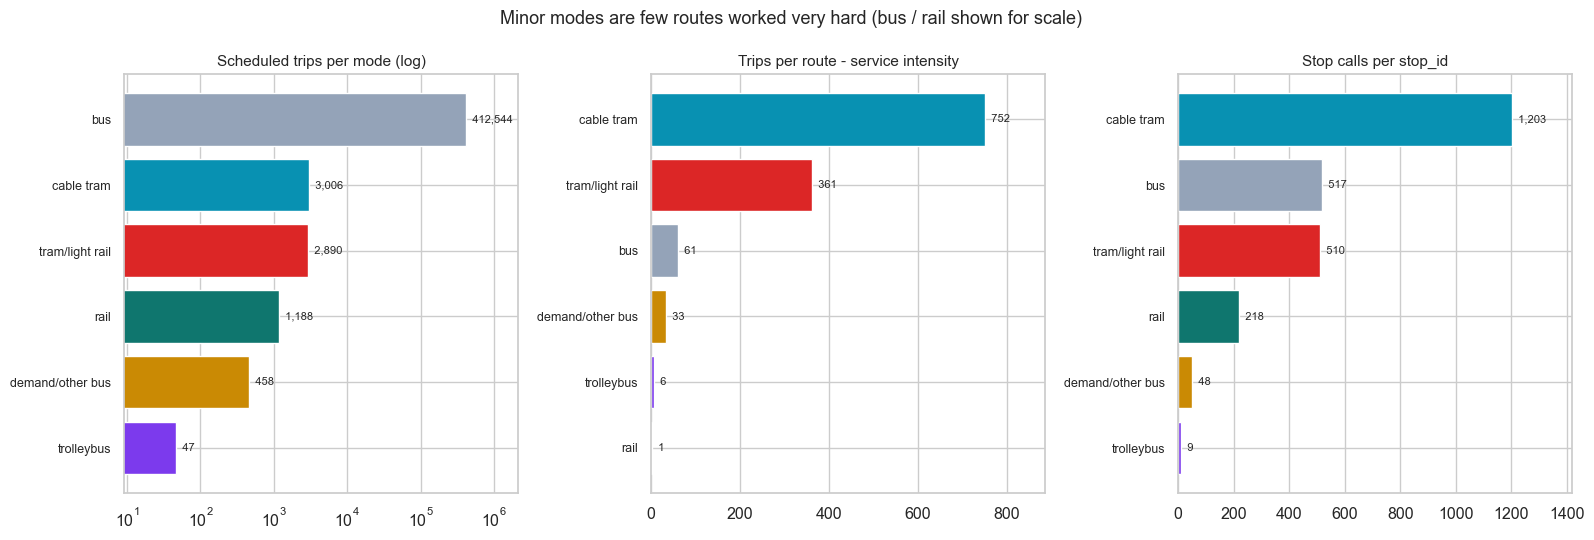

,route_type,mode_label,routes,trips,stops,stop_calls,trips_per_route,calls_per_stop,stops_per_route,is_minor_mode
3,5,cable tram,4,3006,9,10830,751.5,1203.3,2.2,True
0,0,tram/light rail,8,2890,138,70333,361.2,509.7,17.2,True
2,3,bus,6796,412544,30170,15608376,60.7,517.3,4.4,False
5,715,demand/other bus,14,458,153,7390,32.7,48.3,10.9,True
4,8,trolleybus,8,47,10,94,5.9,9.4,1.2,True
1,2,rail,962,1188,67,14601,1.2,217.9,0.1,False


In [11]:
# --- Service intensity for every mode -------------------------------------
intensity_rows = []
for rt in sorted(set(list(ALL_ROUTE_TYPES) + list(mode_calls))):
    stops_n = len(mode_stops.get(rt, ()))
    routes_n = routes_per_mode.get(rt, 0)
    trips_n = trips_per_mode.get(rt, 0)
    intensity_rows.append({
        'route_type': rt,
        'mode_label': MODE_LABELS.get(rt, f'route_type {rt}'),
        'routes': routes_n,
        'trips': trips_n,
        'stops': stops_n,
        'stop_calls': mode_calls.get(rt, 0),
        'trips_per_route': round(trips_n / routes_n, 1) if routes_n else np.nan,
        'calls_per_stop': round(mode_calls.get(rt, 0) / stops_n, 1) if stops_n else np.nan,
        'stops_per_route': round(stops_n / routes_n, 1) if routes_n else np.nan,
        'is_minor_mode': rt in MINOR_ROUTE_TYPES,
    })
intensity = pd.DataFrame(intensity_rows).sort_values('trips_per_route', ascending=False)
intensity.to_csv(TABLES / 'mode_service_intensity.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
panels = [('trips', 'Scheduled trips per mode (log)'),
          ('trips_per_route', 'Trips per route - service intensity'),
          ('calls_per_stop', 'Stop calls per stop_id')]
for ax, (col, title) in zip(axes, panels):
    d = intensity.sort_values(col, ascending=True)
    colors = [MODE_COLORS.get(rt, '#94a3b8') for rt in d['route_type']]
    bars = ax.barh(range(len(d)), d[col].to_numpy(), color=colors)
    ax.set_yticks(range(len(d)))
    ax.set_yticklabels(d['mode_label'], fontsize=9)
    ax.set_title(title, fontsize=11)
    if col == 'trips':
        ax.set_xscale('log')
    for bar, val in zip(bars, d[col].to_numpy()):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f'  {val:,.0f}', va='center', fontsize=8)
    ax.margins(x=0.18)
fig.suptitle('Minor modes are few routes worked very hard (bus / rail shown for scale)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'service_intensity.png', dpi=FIG_DPI)
plt.show()

intensity

## 11. Measure platform-ID duplication

We compare unique `stop_id` count with unique station-name count for each minor mode. Light rail has 138 stop IDs but only 69 distinct names, exactly two IDs per name. The direction-specific platforms do not share trips or edges, so one physical line appears as two disconnected graph corridors.

We do not merge nodes by name. The same name can refer to different physical places, and changing IDs here would make this graph inconsistent with the rest of the analysis. Instead we keep the feed's node definition and quantify the duplication so we can interpret components, calls per stop, and damage with the factor of two in mind.

In [12]:
# --- Platform duplication: stop_ids vs physical station names -------------
dup_rows = []
for rt in MINOR_ROUTE_TYPES:
    ids = set(stop_calls[rt])
    names = {ATTR.get(s, DEFAULT_ATTR)['stop_name'] for s in ids}
    with_parent = sum(1 for s in ids if ATTR.get(s, DEFAULT_ATTR)['parent_station'])
    dup_rows.append({
        'route_type': rt,
        'mode_label': MODE_LABELS[rt],
        'stop_ids': len(ids),
        'distinct_stop_names': len(names),
        'stop_ids_per_name': round(len(ids) / max(len(names), 1), 2),
        'stop_ids_with_parent_station': with_parent,
    })
platform_dup = pd.DataFrame(dup_rows)
platform_dup.to_csv(TABLES / 'platform_duplication.csv', index=False, encoding='utf-8-sig')

for r in platform_dup.itertuples():
    verdict = ('directional platforms are separate stop_ids'
               if r.stop_ids_per_name > 1.5 else 'one stop_id per physical station')
    print(f'{r.mode_label:<18} {r.stop_ids:>4} stop_ids / {r.distinct_stop_names:>4} names '
          f'= {r.stop_ids_per_name:.2f}  ->  {verdict}')
platform_dup

tram/light rail     138 stop_ids /   69 names = 2.00  ->  directional platforms are separate stop_ids
cable tram            9 stop_ids /    9 names = 1.00  ->  one stop_id per physical station
trolleybus           10 stop_ids /    8 names = 1.25  ->  one stop_id per physical station
demand/other bus    153 stop_ids /  117 names = 1.31  ->  one stop_id per physical station


,route_type,mode_label,stop_ids,distinct_stop_names,stop_ids_per_name,stop_ids_with_parent_station
0,0,tram/light rail,138,69,2.00,68
1,5,cable tram,9,9,1.00,0
2,8,trolleybus,10,8,1.25,0
3,715,demand/other bus,153,117,1.31,2


## 12. Measure size, shape, redundancy, and exact centrality

For each undirected mode graph we calculate nodes, edges, components, largest-component share, degree, articulation points, bridges, exact betweenness, service span, and headway at the busiest station. We also classify each component from its degree sequence as isolated, path, cycle, star, tree, or meshed.

The key redundancy measure is the cyclomatic number `m - n + c`. A value of zero means the graph is a forest and has no independent cycle; every edge then lies on the only path between its endpoints. Positive values count independent cycles and show that at least some alternate paths exist.

In this run light rail and cable tram both have cyclomatic number zero. Demand-responsive service has 43 independent cycles, although those can come from flexible trip variants rather than duplicated physical infrastructure.

In [13]:
# --- Structural characterisation of each minor mode -----------------------
def classify_component(H):
    """Name the shape of one connected component from its degree sequence."""
    n, m = H.number_of_nodes(), H.number_of_edges()
    if n == 1:
        return 'isolated'
    degs = sorted(d for _, d in H.degree())
    acyclic = (m == n - 1)
    if acyclic:
        if degs[-1] <= 2:
            return 'path'
        if degs[-1] == n - 1:
            return 'star'
        return 'tree'
    if all(d == 2 for d in degs):
        return 'cycle'
    return 'meshed'


def headway_minutes(departure_lists):
    """Median gap between consecutive departures at the busiest stop, in minutes."""
    if not departure_lists:
        return np.nan
    busiest = max(departure_lists.values(), key=len)
    if len(busiest) < 2:
        return np.nan
    d = np.diff(np.sort(np.asarray(busiest, dtype=float)))
    d = d[d > 0]
    return round(float(np.median(d)) / 60.0, 1) if len(d) else np.nan


BETW = {}
summary_rows, component_rows = [], []
for rt in MINOR_ROUTE_TYPES:
    G, D = graphs[rt]['G'], graphs[rt]['D']
    n, m = G.number_of_nodes(), G.number_of_edges()
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    degs = np.array([d for _, d in G.degree()]) if n else np.array([0])
    ap = sorted(set(nx.articulation_points(G))) if n else []
    br = list(nx.bridges(G)) if n else []
    mu = m - n + len(comps) if n else 0
    BETW[rt] = nx.betweenness_centrality(G, normalized=True) if (n and EXACT_BETWEENNESS) else {}

    shapes = []
    for i, c in enumerate(comps):
        H = G.subgraph(c)
        shape = classify_component(H)
        shapes.append(shape)
        try:
            diam = nx.diameter(H) if len(c) > 1 else 0
        except (nx.NetworkXError, nx.NetworkXNoPath):
            diam = np.nan
        sample = sorted((G.nodes[x]['stop_name'] or x) for x in c)[:3]
        component_rows.append({
            'route_type': rt, 'mode_label': MODE_LABELS[rt], 'component_id': i,
            'nodes': len(c), 'edges': H.number_of_edges(), 'shape': shape,
            'cyclomatic_number': H.number_of_edges() - len(c) + 1,
            'diameter': diam,
            'metro': Counter(G.nodes[x]['metro'] for x in c).most_common(1)[0][0],
            'region': Counter(G.nodes[x]['region'] for x in c).most_common(1)[0][0],
            'sample_stations': ' | '.join(sample),
        })

    deps_all = [d for lst in stop_departures[rt].values() for d in lst]
    calls_total = mode_calls.get(rt, 0)
    stops_total = len(stop_calls[rt])
    summary_rows.append({
        'route_type': rt,
        'mode_label': MODE_LABELS[rt],
        'routes': routes_per_mode.get(rt, 0),
        'trips': trips_per_mode.get(rt, 0),
        'stops': stops_total,
        'graph_nodes': n,
        'directed_edges': D.number_of_edges(),
        'undirected_edges': m,
        'components': len(comps),
        'largest_component_nodes': len(comps[0]) if comps else 0,
        'largest_component_share': round(len(comps[0]) / n, 4) if n else np.nan,
        'avg_degree': round(float(degs.mean()), 2),
        'max_degree': int(degs.max()),
        'density': round(nx.density(G), 5) if n > 1 else np.nan,
        'cyclomatic_number': mu,
        'edges_per_node': round(m / n, 3) if n else np.nan,
        'articulation_points': len(ap),
        'articulation_point_share': round(len(ap) / n, 4) if n else np.nan,
        'bridges': len(br),
        'bridge_share': round(len(br) / m, 4) if m else np.nan,
        'shape_class': ', '.join(f'{v}x {k}' for k, v in Counter(shapes).most_common()),
        'diameter_largest_component': component_rows[-len(comps)]['diameter'] if comps else np.nan,
        'trips_per_route': round(trips_per_mode.get(rt, 0) / routes_per_mode.get(rt, 1), 1),
        'stop_calls': calls_total,
        'calls_per_stop': round(calls_total / stops_total, 1) if stops_total else np.nan,
        'max_calls_at_a_stop': max(stop_calls[rt].values()) if stops_total else 0,
        'first_departure': hhmm(min(deps_all)) if deps_all else '',
        'last_departure': hhmm(max(deps_all)) if deps_all else '',
        'service_span_hours': round((max(deps_all) - min(deps_all)) / 3600, 1) if deps_all else np.nan,
        'departures_after_midnight': int(sum(1 for d in deps_all if d >= 86400)),
        'median_headway_busiest_stop_minutes': headway_minutes(stop_departures[rt]),
        'max_exact_betweenness': round(max(BETW[rt].values()), 4) if BETW[rt] else np.nan,
        'exact_betweenness': bool(EXACT_BETWEENNESS),
    })

minor_summary = pd.DataFrame(summary_rows)
minor_summary.to_csv(TABLES / 'minor_modes_summary.csv', index=False, encoding='utf-8-sig')
components_df = pd.DataFrame(component_rows)
components_df.to_csv(TABLES / 'minor_mode_components.csv', index=False, encoding='utf-8-sig')

print('saved:', TABLES / 'minor_modes_summary.csv')
print('saved:', TABLES / 'minor_mode_components.csv')
display(minor_summary[['mode_label', 'graph_nodes', 'undirected_edges', 'components',
                       'avg_degree', 'max_degree', 'cyclomatic_number', 'shape_class',
                       'articulation_points', 'bridges']])
components_df

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\16_lightrail_and_minor_modes\tables\minor_modes_summary.csv
saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\16_lightrail_and_minor_modes\tables\minor_mode_components.csv


,mode_label,graph_nodes,undirected_edges,components,avg_degree,max_degree,cyclomatic_number,shape_class,articulation_points,bridges
0,tram/light rail,138,134,4,1.94,3,0,"2x path, 2x tree",128,134
1,cable tram,9,7,2,1.56,2,0,2x path,5,7
2,trolleybus,8,5,3,1.25,3,0,"2x path, 1x star",1,5
3,demand/other bus,153,194,2,2.54,6,43,2x meshed,21,12


,route_type,mode_label,component_id,nodes,edges,shape,cyclomatic_number,diameter,metro,region,sample_stations
0,0,tram/light rail,0,35,34,path,0,34,Jerusalem,Jerusalem,א-סהל | בית הספר לרפואה | בית חנינא
1,0,tram/light rail,1,35,34,path,0,34,Jerusalem,Jerusalem,א-סהל | בית הספר לרפואה | בית חנינא
2,0,tram/light rail,2,34,33,tree,0,31,Tel Aviv,Center,אבא הלל | אהרונוביץ' | איסקוב
3,0,tram/light rail,3,34,33,tree,0,31,Tel Aviv,Center,אבא הלל | אהרונוביץ' | איסקוב
4,5,cable tram,0,6,5,path,0,5,Haifa,North,ביה''ח בני ציון | הדר העירייה | הנביאים
5,5,cable tram,1,3,2,path,0,2,Haifa,North,אוניברסיטת חיפה | טכניון מרכז | מרכזית המפרץ
6,8,trolleybus,0,4,3,star,0,2,Tel Aviv,Center,תחנת מוניות תל אביב מסוף רדינג | תחנת מוניות ת...
7,8,trolleybus,1,2,1,path,0,1,Tel Aviv,Center,תחנת מוניות תל אביב מסוף רדינג | תחנת מוניות ת...
8,8,trolleybus,2,2,1,path,0,1,Tel Aviv,Center,תחנת מוניות רמת גן דרך הטייסים | תחנת מוניות ת...
9,715,demand/other bus,0,129,164,meshed,36,23,Periphery,Center,'כפר הרי''ף א | אביעזר/מרכז א | אביעזר/מרכז ב


### 12a. Translate the redundancy values into failure meaning

We print a short interpretation for every mode. For a forest, every edge is a bridge and almost every non-leaf station is an articulation point, so a binary “critical or not” flag is not very selective. We then need the amount of disconnected service or station pairs to rank the cut points.

The output makes the contrast clear: light rail has 128 articulation points out of 138 stop IDs and all 134 links are bridges. Cable tram also has every link as a bridge. Demand-responsive service has cycles, only 21 articulation points, and 12 bridges out of 194 edges.

In [14]:
# --- Redundancy verdict per mode ------------------------------------------
for r in minor_summary.itertuples():
    if r.graph_nodes == 0:
        print(f'{r.mode_label:<18} no graph (no multi-stop trips)')
        continue
    if r.cyclomatic_number == 0:
        verdict = ('FOREST - zero independent cycles: exactly one path between any two '
                   'stations, every link is a bridge')
    else:
        verdict = (f'{r.cyclomatic_number} independent cycle(s): some alternative paths exist')
    print(f'{r.mode_label:<18} n={r.graph_nodes:<4} m={r.undirected_edges:<4} '
          f'mu={r.cyclomatic_number:<3} AP={r.articulation_points} '
          f'({r.articulation_point_share:.0%} of stations)  bridges={r.bridges} '
          f'({r.bridge_share:.0%} of links)')
    print(f'{"":<18} -> {verdict}')

print()
print('For contrast, the national (mostly bus) graph in notebook 03 has articulation points')
print('at roughly 3% of its stations and bridges on under 2% of its links.')

tram/light rail    n=138  m=134  mu=0   AP=128 (93% of stations)  bridges=134 (100% of links)
                   -> FOREST - zero independent cycles: exactly one path between any two stations, every link is a bridge
cable tram         n=9    m=7    mu=0   AP=5 (56% of stations)  bridges=7 (100% of links)
                   -> FOREST - zero independent cycles: exactly one path between any two stations, every link is a bridge
trolleybus         n=8    m=5    mu=0   AP=1 (12% of stations)  bridges=5 (100% of links)
                   -> FOREST - zero independent cycles: exactly one path between any two stations, every link is a bridge
demand/other bus   n=153  m=194  mu=43  AP=21 (14% of stations)  bridges=12 (6% of links)
                   -> 43 independent cycle(s): some alternative paths exist

For contrast, the national (mostly bus) graph in notebook 03 has articulation points
at roughly 3% of its stations and bridges on under 2% of its links.


## 13. Save exact station-level metrics

We write one row per graph node across all four minor modes to `lightrail_station_metrics.csv`. The first columns are the reusable station ID, name, coordinates, degree, weighted degree, and mode label. We append exact betweenness, call count, route count, articulation status, component, region, and metro area.

`weighted_degree` is the sum of service frequency on incident undirected edges. It is a scheduled-load measure, while exact betweenness is a within-mode path-position measure. We sort by mode and betweenness and print the leading light-rail and high-service stations to make sure the values follow the expected corridor pattern.

In [15]:
# --- Station metrics for every minor mode ---------------------------------
station_rows = []
for rt in MINOR_ROUTE_TYPES:
    G = graphs[rt]['G']
    if G.number_of_nodes() == 0:
        continue
    comp_of = {node: i for i, c in enumerate(
        sorted(nx.connected_components(G), key=len, reverse=True)) for node in c}
    ap = set(nx.articulation_points(G))
    wdeg = dict(G.degree(weight='weight'))
    for node, data in G.nodes(data=True):
        station_rows.append({
            'stop_id': node,
            'stop_name': data.get('stop_name', ''),
            'lat': data.get('lat'),
            'lon': data.get('lon'),
            'degree': G.degree(node),
            'weighted_degree': int(wdeg.get(node, 0)),
            'mode_label': MODE_LABELS[rt],
            'route_type': rt,
            'exact_betweenness': round(BETW[rt].get(node, 0.0), 6),
            'stop_calls': int(stop_calls[rt].get(node, 0)),
            'n_routes': len(stop_routes[rt].get(node, ())),
            'is_articulation_point': node in ap,
            'component_id': comp_of.get(node, -1),
            'region': data.get('region', ''),
            'metro': data.get('metro', ''),
        })

station_metrics = (pd.DataFrame(station_rows)
                   .sort_values(['route_type', 'exact_betweenness', 'weighted_degree'],
                                ascending=[True, False, False])
                   .reset_index(drop=True))
station_metrics.to_csv(TABLES / 'lightrail_station_metrics.csv', index=False, encoding='utf-8-sig')
print('saved:', TABLES / 'lightrail_station_metrics.csv',
      f'({len(station_metrics):,} stations across {station_metrics["mode_label"].nunique()} modes)')

missing_coords = station_metrics[['lat', 'lon']].isna().any(axis=1).sum()
print('stations with missing coordinates:', int(missing_coords))

print('\nTop light-rail stations by exact betweenness:')
display(station_metrics[station_metrics['route_type'] == 0]
        .head(TOP_N)[['stop_name', 'metro', 'degree', 'weighted_degree',
                      'exact_betweenness', 'stop_calls', 'is_articulation_point']])
print('Busiest stations of every minor mode (by services crossing the station):')
station_metrics.sort_values('weighted_degree', ascending=False).head(TOP_N)[
    ['mode_label', 'stop_name', 'metro', 'degree', 'weighted_degree', 'stop_calls']]

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\16_lightrail_and_minor_modes\tables\lightrail_station_metrics.csv (308 stations across 4 modes)
stations with missing coordinates: 0

Top light-rail stations by exact betweenness:


,stop_name,metro,degree,weighted_degree,exact_betweenness,stop_calls,is_articulation_point
0,יפו - מרכז,Jerusalem,2,500,0.031022,250,True
1,יפו - מרכז,Jerusalem,2,464,0.031022,232,True
2,העירייה,Jerusalem,2,500,0.030915,250,True
3,הדווידקה,Jerusalem,2,500,0.030915,250,True
4,הדווידקה,Jerusalem,2,464,0.030915,232,True
5,העירייה,Jerusalem,2,464,0.030915,232,True
6,שער שכם,Jerusalem,2,500,0.030593,250,True
7,מחנה יהודה,Jerusalem,2,500,0.030593,250,True
8,מחנה יהודה,Jerusalem,2,464,0.030593,232,True
9,שער שכם,Jerusalem,2,464,0.030593,232,True


Busiest stations of every minor mode (by services crossing the station):


,mode_label,stop_name,metro,degree,weighted_degree,stop_calls
142,cable tram,טכניון מרכז,Haifa,2,4804,2402
34,tram/light rail,ארלוזורוב,Tel Aviv,2,2436,1218
22,tram/light rail,יהודית,Tel Aviv,2,2436,1218
42,tram/light rail,אבא הלל,Tel Aviv,2,2436,1218
55,tram/light rail,אהרונוביץ',Tel Aviv,3,2436,1218
54,tram/light rail,בן גוריון,Tel Aviv,2,2436,1218
19,tram/light rail,קרליבך,Tel Aviv,2,2436,1218
26,tram/light rail,שאול המלך,Tel Aviv,2,2436,1218
18,tram/light rail,אלנבי,Tel Aviv,2,2436,1218
46,tram/light rail,ביאליק,Tel Aviv,2,2436,1218


## 14. Map each minor-mode graph

We draw one panel per mode with actual graph edges between station coordinates. Node size reflects weighted degree, so frequently served points stand out. Each panel gets its own extent and corrected aspect ratio because these modes operate in very different parts of the country.

The map is meant to show that these are local systems rather than a national layer: light rail in Jerusalem and Tel Aviv, cable systems in Haifa, shared taxis around Tel Aviv, and demand-responsive clusters in rural areas. Stations without finite coordinates are counted and left out.

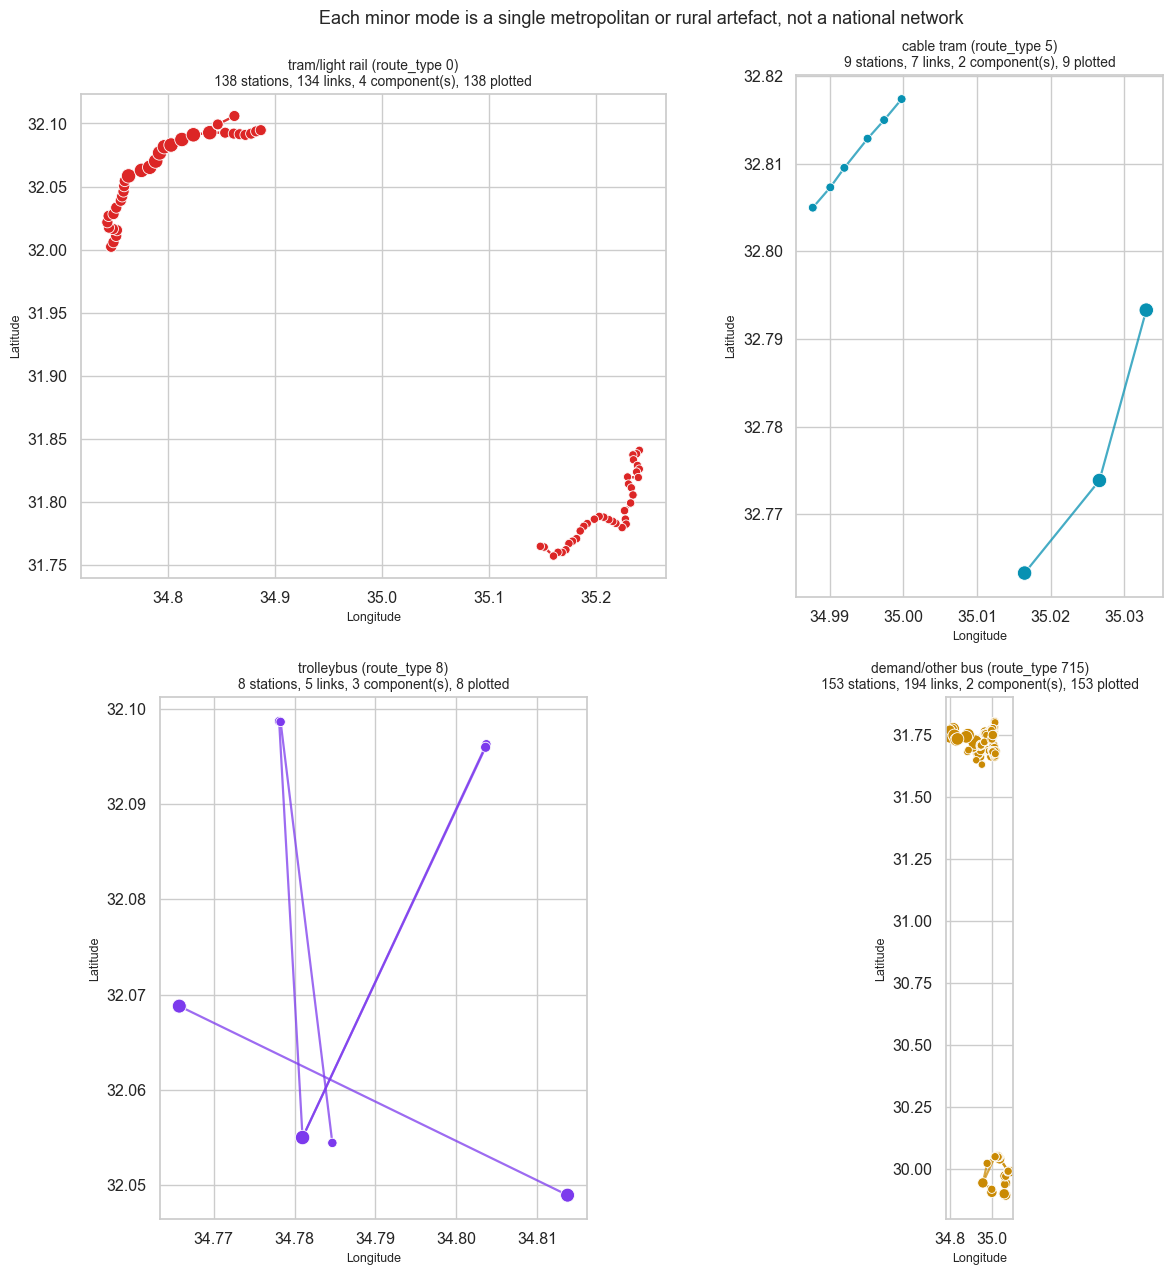

In [16]:
# --- One geographic panel per mode ----------------------------------------
def has_coords(data):
    """True only when both coordinates are present and finite (0.0 included)."""
    lat, lon = data.get('lat'), data.get('lon')
    return (lat is not None and lon is not None
            and np.isfinite(lat) and np.isfinite(lon))


def draw_mode(ax, rt, label_stations=False, max_labels=MAX_LABELLED_STATIONS, nodes=None):
    """Draw one mode's graph on `ax`; returns the number of stations plotted."""
    G = graphs[rt]['G']
    sub = G.subgraph(nodes) if nodes is not None else G
    pts = {n: (d['lon'], d['lat']) for n, d in sub.nodes(data=True) if has_coords(d)}
    if not pts:
        ax.set_axis_off()
        ax.set_title(f'{MODE_LABELS[rt]} - no usable coordinates')
        return 0
    for u, v, d in sub.edges(data=True):
        if u in pts and v in pts:
            ax.plot([pts[u][0], pts[v][0]], [pts[u][1], pts[v][1]],
                    color=MODE_COLORS.get(rt, '#475569'), linewidth=1.6, alpha=0.75, zorder=1)
    load = np.array([stop_calls[rt].get(n, 0) for n in pts], dtype=float)
    sizes = 18 + 90 * (load / load.max()) if load.max() > 0 else np.full(len(pts), 25.0)
    xs = [p[0] for p in pts.values()]
    ys = [p[1] for p in pts.values()]
    ax.scatter(xs, ys, s=sizes, c=MODE_COLORS.get(rt, '#475569'),
               edgecolors='white', linewidths=0.6, zorder=2)
    if label_stations and len(pts) <= max_labels:
        placed = set()
        for n, (x, y) in pts.items():
            name = sub.nodes[n].get('stop_name', '') or n
            if name in placed:          # both directional platforms carry the same name
                continue
            placed.add(name)
            ax.annotate(name, (x, y), fontsize=7, xytext=(3, 3),
                        textcoords='offset points', zorder=3)
    ax.set_aspect(1 / np.cos(np.deg2rad(float(np.mean(ys)))))
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    return len(pts)


fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, rt in zip(axes.ravel(), MINOR_ROUTE_TYPES):
    plotted = draw_mode(ax, rt)
    row = minor_summary.loc[minor_summary['route_type'] == rt].iloc[0]
    ax.set_title(f'{MODE_LABELS[rt]} (route_type {rt})\n'
                 f'{row.graph_nodes} stations, {row.undirected_edges} links, '
                 f'{row.components} component(s), {plotted} plotted', fontsize=10)
fig.suptitle('Each minor mode is a single metropolitan or rural artefact, not a national network',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'mode_network_maps.png', dpi=FIG_DPI)
plt.show()

### 14a. Label the light-rail and cable corridors

We split light rail by metro area and label each distinct station name once, so the Jerusalem and Tel Aviv systems can be read as separate corridors without duplicating both platform IDs in the text. We make a similar labeled view of the two cable components in Haifa.

These figures are a visual check on the component classification. Paths should look like chains, while the few degree-3 light-rail nodes should correspond to short branches rather than a broadly meshed network.

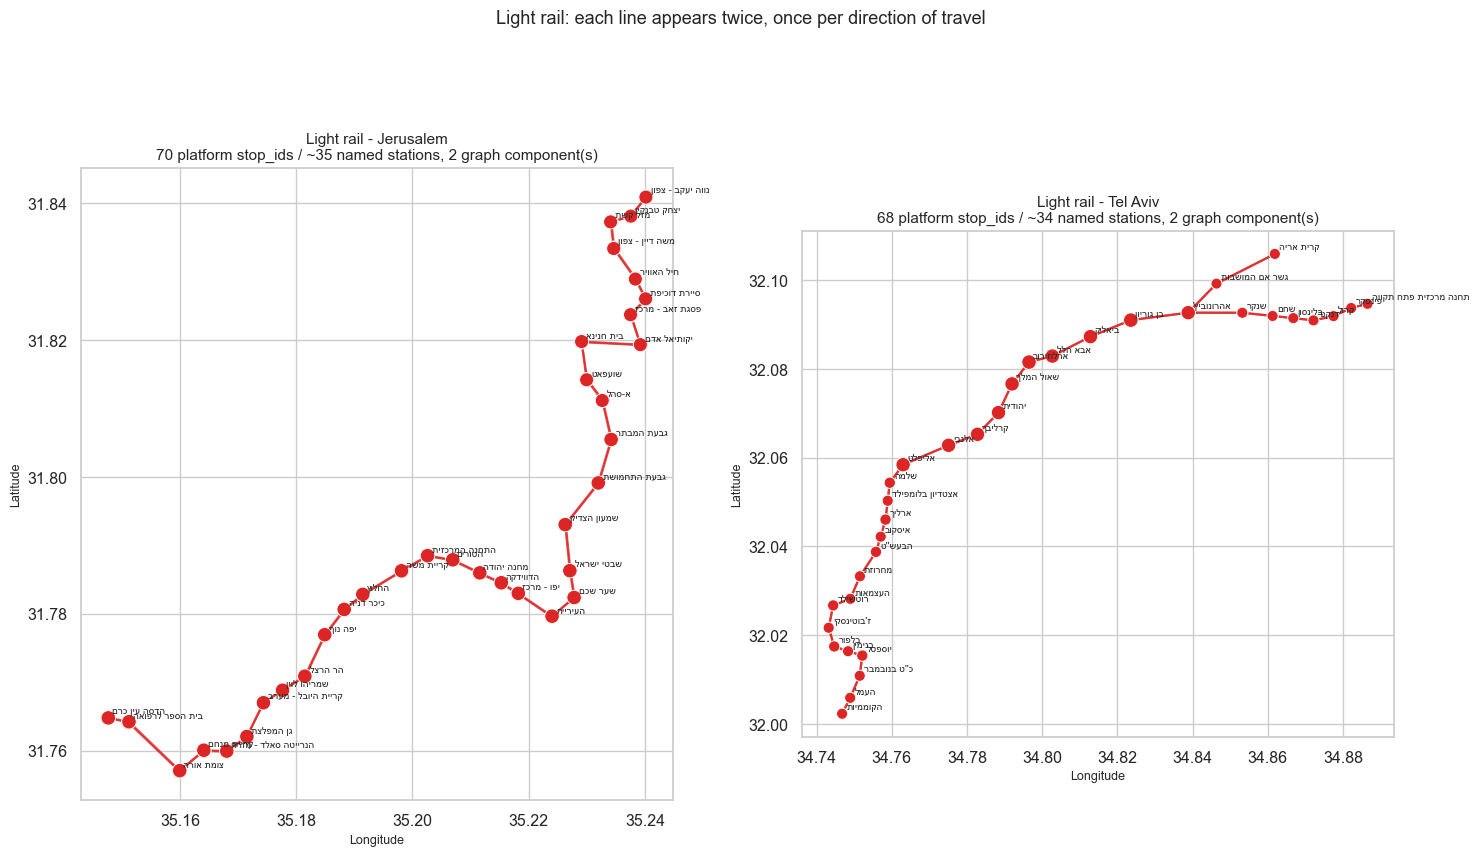

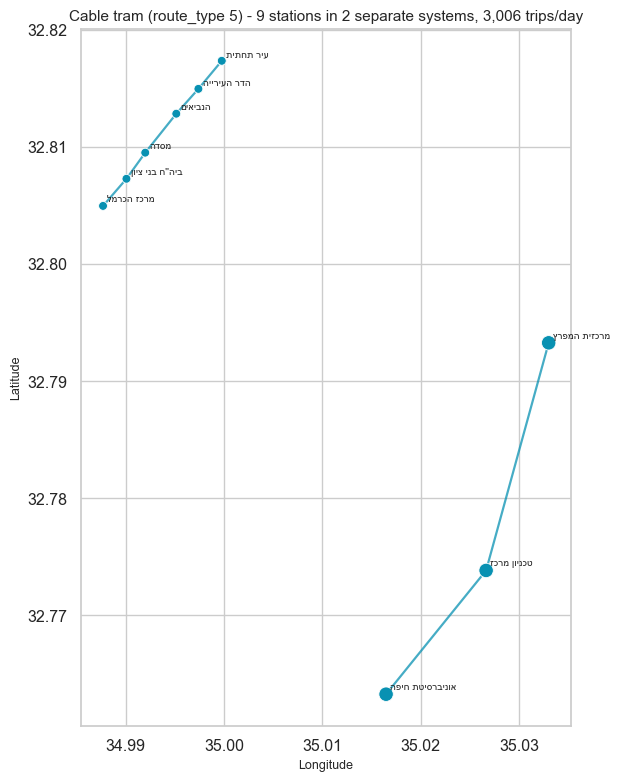

In [17]:
# --- Labelled maps: light rail by metro, then cable tram ------------------
G0 = graphs[0]['G']
groups = defaultdict(list)
for n, d in G0.nodes(data=True):
    groups[d.get('metro') or d.get('region') or 'unknown'].append(n)
groups = dict(sorted(groups.items(), key=lambda kv: -len(kv[1])))

if groups:
    fig, axes = plt.subplots(1, len(groups), figsize=(7.5 * len(groups), 9.5))
    axes = np.atleast_1d(axes)
    for ax, (metro, nodes) in zip(axes, groups.items()):
        plotted = draw_mode(ax, 0, label_stations=True, nodes=nodes)
        sub = G0.subgraph(nodes)
        ncomp = nx.number_connected_components(sub)
        names = len({sub.nodes[n]['stop_name'] for n in nodes})
        ax.set_title(f'Light rail - {metro}\n{len(nodes)} platform stop_ids / ~{names} named '
                     f'stations, {ncomp} graph component(s)', fontsize=11)
    fig.suptitle('Light rail: each line appears twice, once per direction of travel', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES / 'lightrail_labeled_map.png', dpi=FIG_DPI)
    plt.show()

fig, ax = plt.subplots(figsize=(7.5, 8))
draw_mode(ax, 5, label_stations=True)
row5 = minor_summary.loc[minor_summary['route_type'] == 5].iloc[0]
ax.set_title(f'Cable tram (route_type 5) - {row5.graph_nodes} stations in '
             f'{row5.components} separate systems, {row5.trips:,} trips/day', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'cabletram_labeled_map.png', dpi=FIG_DPI)
plt.show()

## 15. Inspect exact betweenness profiles

We plot the sorted exact betweenness values for every minor mode and list the highest stations. In a simple path, betweenness rises toward the middle and falls to zero at the terminals. Branches or junctions change that shape, so the profile helps us distinguish a pure corridor from a more complex component.

The values are exact within each graph, but normalized separately. We can rank stations inside a mode; we should not compare a value of 0.2 in a nine-node cable graph directly with 0.2 in the national graph.

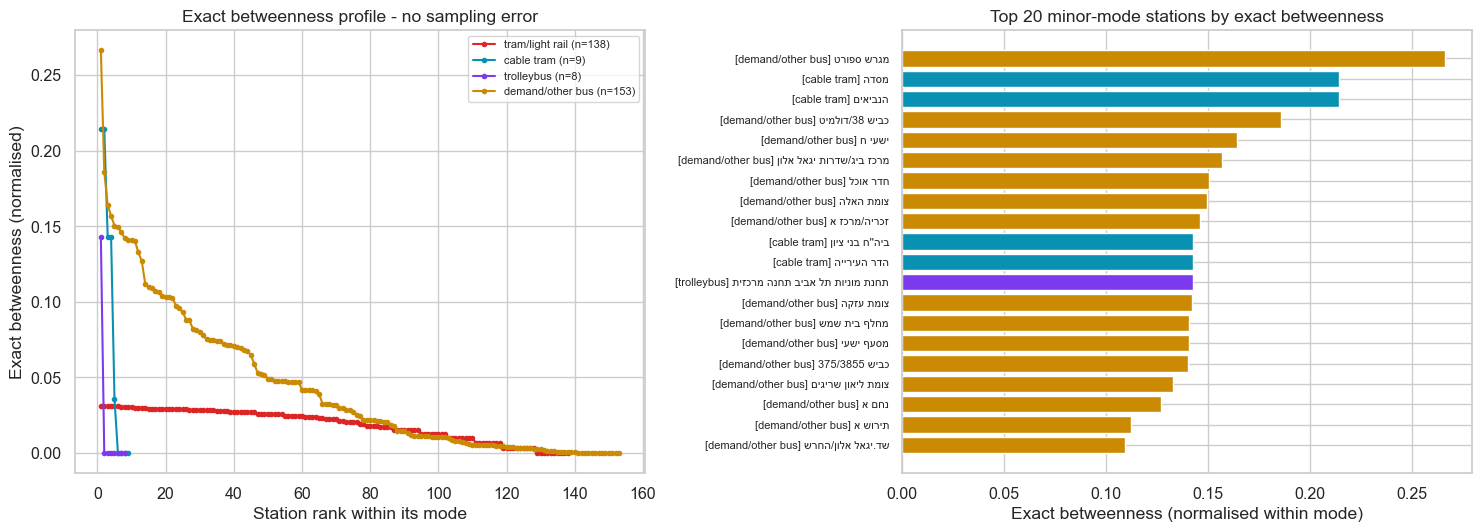

,mode_label,stop_name,metro,degree,weighted_degree,exact_betweenness,is_articulation_point
155,demand/other bus,מגרש ספורט,Periphery,5,218,0.266439,True
139,cable tram,מסדה,Haifa,2,1208,0.214286,True
138,cable tram,הנביאים,Haifa,2,1208,0.214286,True
156,demand/other bus,כביש 38/דולמיט,Periphery,6,142,0.186037,False
157,demand/other bus,ישעי ח,Periphery,3,96,0.164216,False
158,demand/other bus,מרכז ביג/שדרות יגאל אלון,Periphery,3,96,0.156882,False
159,demand/other bus,חדר אוכל,Periphery,4,86,0.150472,False
160,demand/other bus,צומת האלה,Periphery,3,88,0.149711,False
161,demand/other bus,זכריה/מרכז א,Periphery,3,96,0.146140,False
141,cable tram,ביה''ח בני ציון,Haifa,2,1208,0.142857,True


In [18]:
# --- Exact betweenness profiles -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for rt in MINOR_ROUTE_TYPES:
    vals = sorted(BETW[rt].values(), reverse=True)
    if not vals:
        continue
    axes[0].plot(range(1, len(vals) + 1), vals, marker='o', markersize=3,
                 color=MODE_COLORS.get(rt), label=f'{MODE_LABELS[rt]} (n={len(vals)})')
axes[0].set_xlabel('Station rank within its mode')
axes[0].set_ylabel('Exact betweenness (normalised)')
axes[0].set_title('Exact betweenness profile - no sampling error')
axes[0].legend(fontsize=8)

top_bt = (station_metrics.sort_values('exact_betweenness', ascending=False)
          .head(TOP_N).iloc[::-1])
axes[1].barh(range(len(top_bt)),
             top_bt['exact_betweenness'].to_numpy(),
             color=[MODE_COLORS.get(rt, '#475569') for rt in top_bt['route_type']])
axes[1].set_yticks(range(len(top_bt)))
axes[1].set_yticklabels([f'{r.stop_name} [{r.mode_label}]' for r in top_bt.itertuples()],
                        fontsize=8)
axes[1].set_xlabel('Exact betweenness (normalised within mode)')
axes[1].set_title(f'Top {TOP_N} minor-mode stations by exact betweenness')
plt.tight_layout()
plt.savefig(FIGURES / 'exact_betweenness.png', dpi=FIG_DPI)
plt.show()

station_metrics.sort_values('exact_betweenness', ascending=False).head(TOP_N)[
    ['mode_label', 'stop_name', 'metro', 'degree', 'weighted_degree',
     'exact_betweenness', 'is_articulation_point']]

## 16. Remove every station and measure exact damage

These graphs are small enough that we can delete each node once and recompute connected components exactly. For every removal we record the largest surviving component and the share of previously connected station pairs that become disconnected, excluding pairs involving the removed station itself.

The pair-disconnection share is the more informative measure for corridor graphs. A middle station in a path separates two large sides, while a terminal leaves the remaining path connected. In this run the maximum pair-disconnection share is 0.127 for light rail, 0.462 for cable tram, 0.600 for the tiny taxi-coded layer, and 0.166 for demand-responsive service.

This is damage inside one mode only. A rider switching to a nearby bus is not represented here.

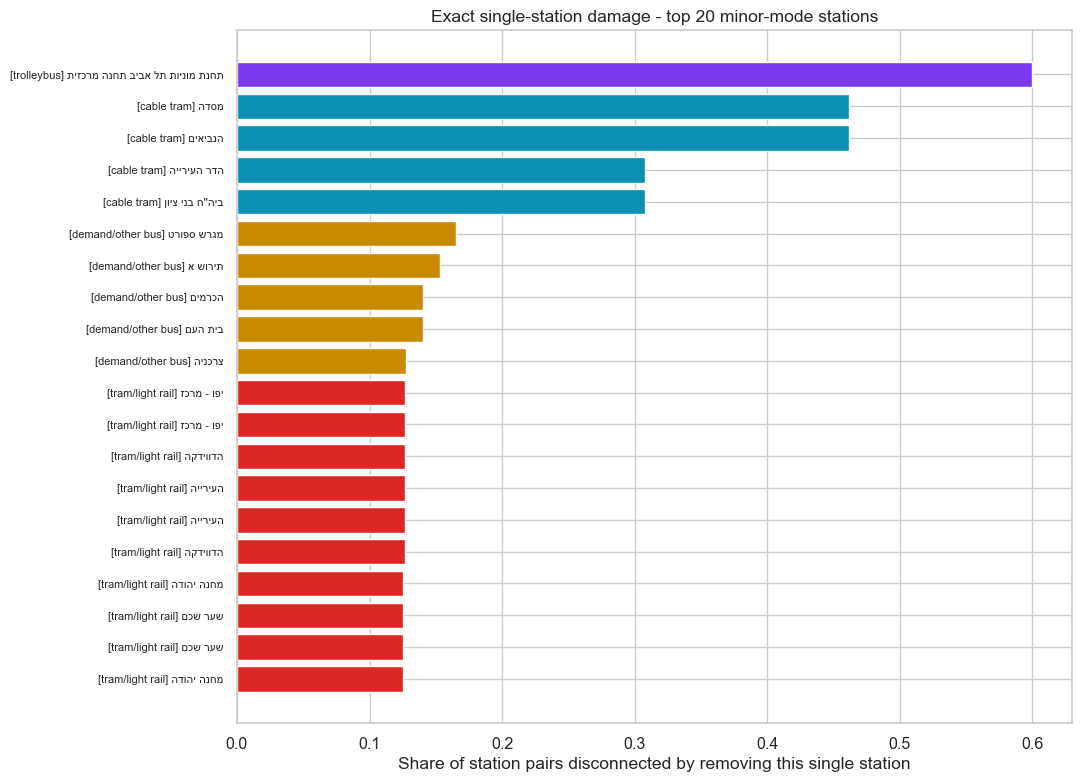

Mean share of pairs disconnected by removing one station, per mode:
                   mean    max  count
mode_label                           
cable tram        0.178  0.462      9
demand/other bus  0.007  0.166    153
tram/light rail   0.078  0.127    138
trolleybus        0.075  0.600      8


In [19]:
# --- Remove every station in turn (exact, no sampling) --------------------
def single_station_damage(G):
    """Exact damage caused by removing each node once."""
    comps = list(nx.connected_components(G))
    size_of = {n: len(c) for c in comps for n in c}
    base_pairs = sum(len(c) * (len(c) - 1) // 2 for c in comps)
    n = G.number_of_nodes()
    out = []
    for node in G.nodes():
        H = G.copy()
        H.remove_node(node)
        after = list(nx.connected_components(H))
        pairs_after = sum(len(c) * (len(c) - 1) // 2 for c in after)
        # pairs that existed among the OTHER nodes before the removal
        baseline = base_pairs - (size_of[node] - 1)
        largest = max((len(c) for c in after), default=0)
        out.append({
            'stop_id': node,
            'largest_component_share_surviving': round(largest / (n - 1), 4) if n > 1 else np.nan,
            'pairs_disconnected_share': round(1 - pairs_after / baseline, 4) if baseline else 0.0,
            'components_after': len(after),
        })
    return pd.DataFrame(out)


damage_frames = []
for rt in MINOR_ROUTE_TYPES:
    G = graphs[rt]['G']
    if G.number_of_nodes() < 2:
        continue
    d = single_station_damage(G)
    d['route_type'] = rt
    d['mode_label'] = MODE_LABELS[rt]
    damage_frames.append(d)

damage = pd.concat(damage_frames, ignore_index=True)
damage = damage.merge(
    station_metrics[['stop_id', 'route_type', 'stop_name', 'metro', 'degree',
                     'weighted_degree', 'exact_betweenness', 'is_articulation_point']],
    on=['stop_id', 'route_type'], how='left')
damage = damage.sort_values(['route_type', 'pairs_disconnected_share'],
                            ascending=[True, False]).reset_index(drop=True)
damage.to_csv(TABLES / 'minor_mode_single_station_damage.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(11, 8))
top_dmg = damage.sort_values('pairs_disconnected_share', ascending=False).head(TOP_N).iloc[::-1]
ax.barh(range(len(top_dmg)), top_dmg['pairs_disconnected_share'].to_numpy(),
        color=[MODE_COLORS.get(rt, '#475569') for rt in top_dmg['route_type']])
ax.set_yticks(range(len(top_dmg)))
ax.set_yticklabels([f'{r.stop_name} [{r.mode_label}]' for r in top_dmg.itertuples()], fontsize=8)
ax.set_xlabel('Share of station pairs disconnected by removing this single station')
ax.set_title(f'Exact single-station damage - top {TOP_N} minor-mode stations')
plt.tight_layout()
plt.savefig(FIGURES / 'single_station_damage.png', dpi=FIG_DPI)
plt.show()

print('Mean share of pairs disconnected by removing one station, per mode:')
print(damage.groupby('mode_label')['pairs_disconnected_share']
      .agg(['mean', 'max', 'count']).round(3).to_string())

## 17. Place the minor modes inside the national components

If notebook 02's graph is available, we label every national connected component by the modes serving its station IDs. This shows what creates the small components outside the giant bus component.

The result is mostly a station-ID effect. The 67-node rail component, four light-rail platform components, two cable components, and taxi-coded stubs all sit apart because they share no stop ID with bus. Demand-responsive service is different: 81 of its 153 stations share regular bus IDs and most of it joins the giant component.

This tells us not to interpret “disconnected in the stop-ID graph” as “impossible to transfer in the real system.” Walking between nearby platform and bus records has to be modeled spatially, which we do in notebook 17.

In [20]:
# --- Optional: locate the minor modes in the national graph ---------------
if nodes_path is None or edges_path is None:
    print('notebook 02 artifacts not found - national placement cross-check skipped '
          '(run 02_graph_construction to enable it).')
else:
    nat_edges = pd.read_csv(edges_path, dtype={'from_stop': str, 'to_stop': str},
                            encoding='utf-8-sig')
    NAT = nx.from_pandas_edgelist(nat_edges, 'from_stop', 'to_stop')
    nat_comps = sorted(nx.connected_components(NAT), key=len, reverse=True)

    stop_to_modes = defaultdict(set)
    for rt, stops in mode_stops.items():
        for s in stops:
            stop_to_modes[s].add(rt)

    rows = []
    for i, c in enumerate(nat_comps):
        counts = Counter()
        for s in c:
            for rt in stop_to_modes.get(s, ()):
                counts[rt] += 1
        rows.append({
            'component_rank': i,
            'nodes': len(c),
            'modes_present': ', '.join(f'{MODE_LABELS.get(rt, rt)}:{v}'
                                       for rt, v in counts.most_common()),
            'dominant_mode': MODE_LABELS.get(counts.most_common(1)[0][0], '?') if counts else '?',
            'sample_station': sorted(ATTR.get(s, DEFAULT_ATTR)['stop_name'] for s in c)[0],
        })
    nat_comp_df = pd.DataFrame(rows)
    nat_comp_df.to_csv(TABLES / 'national_component_modes.csv', index=False, encoding='utf-8-sig')

    print(f'national graph: {NAT.number_of_nodes():,} nodes, {len(nat_comps)} components')
    display(nat_comp_df)

    # How many stops of each minor mode are shared with another mode at all?
    print('Stops shared with at least one other mode (same stop_id):')
    for rt in MINOR_ROUTE_TYPES:
        stops = mode_stops.get(rt, set())
        shared = sum(1 for s in stops if len(stop_to_modes[s]) > 1)
        print(f'  {MODE_LABELS[rt]:<18} {shared:>4} / {len(stops):<4} '
              f'({shared / max(len(stops), 1):.0%}) - '
              f'{"integrated with the bus network" if shared else "no shared stop_id with any other mode"}')

national graph: 30,463 nodes, 12 components


,component_rank,nodes,modes_present,dominant_mode,sample_station
0,0,30237,"bus:30165, demand/other bus:153",bus,מסעף נווה מונסון/כביש 412
1,1,67,rail:67,rail,אופקים
2,2,35,tram/light rail:35,tram/light rail,א-סהל
3,3,35,tram/light rail:35,tram/light rail,א-סהל
4,4,34,tram/light rail:34,tram/light rail,אבא הלל
5,5,34,tram/light rail:34,tram/light rail,אבא הלל
6,6,6,cable tram:6,cable tram,ביה''ח בני ציון
7,7,4,bus:4,bus,בית ספר ישורון/קלאוזנר
8,8,4,trolleybus:4,trolleybus,תחנת מוניות תל אביב מסוף רדינג
9,9,3,cable tram:3,cable tram,אוניברסיטת חיפה


Stops shared with at least one other mode (same stop_id):
  tram/light rail       0 / 138  (0%) - no shared stop_id with any other mode
  cable tram            0 / 9    (0%) - no shared stop_id with any other mode
  trolleybus            0 / 10   (0%) - no shared stop_id with any other mode
  demand/other bus     81 / 153  (53%) - integrated with the bus network


## 18. Examine the time-of-day service profile

Using the decoded service-day seconds, we count departures by hour without folding hours 24 and above back to zero. We also summarize first departure, last departure, service span, after-midnight count, and median headway at each mode's busiest stop.

The result separates continuous high-frequency corridors from sparse niche services. Light rail spans about 25.1 service-day hours with a one-minute median headway at its busiest recorded platform; cable tram has a 0.7-minute value at its busiest station; the taxi-coded layer runs roughly 07:00-17:08 with far fewer calls. These are schedule records, so duplicated platforms and synchronized trips can affect the raw headway values.

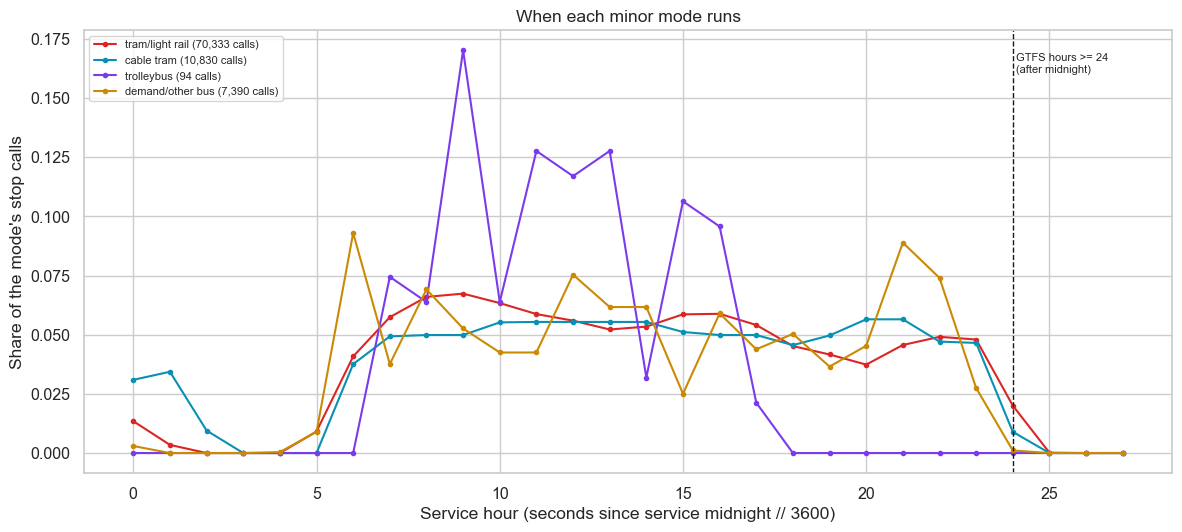

,mode_label,first_departure,last_departure,service_span_hours,departures_after_midnight,median_headway_busiest_stop_minutes,max_calls_at_a_stop
0,tram/light rail,00:00,25:04,25.1,1421,1.0,1218
1,cable tram,00:00,24:35,24.6,97,0.7,2402
2,trolleybus,07:00,17:08,10.1,0,8.0,34
3,demand/other bus,00:03,24:14,24.2,8,7.5,170


In [21]:
# --- Departures per service hour ------------------------------------------
hour_rows = []
for rt in MINOR_ROUTE_TYPES:
    deps = [d for lst in stop_departures[rt].values() for d in lst]
    counts = Counter(d // 3600 for d in deps)
    for h in range(0, 28):
        hour_rows.append({'route_type': rt, 'mode_label': MODE_LABELS[rt],
                          'service_hour': h, 'departures': counts.get(h, 0)})
hourly = pd.DataFrame(hour_rows)
hourly.to_csv(TABLES / 'hourly_departures.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(12, 5.5))
for rt in MINOR_ROUTE_TYPES:
    d = hourly[hourly['route_type'] == rt]
    total = d['departures'].sum()
    if total == 0:
        continue
    ax.plot(d['service_hour'], d['departures'] / total, marker='o', markersize=3,
            color=MODE_COLORS.get(rt), label=f'{MODE_LABELS[rt]} ({total:,} calls)')
ax.axvline(24, color='#111827', linestyle='--', linewidth=1)
ax.text(24.1, ax.get_ylim()[1] * 0.9, 'GTFS hours >= 24\n(after midnight)', fontsize=8)
ax.set_xlabel('Service hour (seconds since service midnight // 3600)')
ax.set_ylabel('Share of the mode\'s stop calls')
ax.set_title('When each minor mode runs')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / 'hourly_departures.png', dpi=FIG_DPI)
plt.show()

minor_summary[['mode_label', 'first_departure', 'last_departure', 'service_span_hours',
               'departures_after_midnight', 'median_headway_busiest_stop_minutes',
               'max_calls_at_a_stop']]

## 19. Save the graphs and summary

We collect the main mode, component, intensity, timing, and damage values in `lightrail_summary.json`. We pickle the four undirected graphs in one dictionary and list every table and figure written by the notebook with its size.

This final check makes sure the reusable graphs and contract tables exist before we move on, and that all artifacts stayed inside `outputs/nb/16_lightrail_and_minor_modes/`.

In [22]:
# --- Stage summary and artifacts ------------------------------------------
lr = minor_summary.loc[minor_summary['route_type'] == 0].iloc[0]
bus_row = intensity.loc[intensity['route_type'] == 3]
bus_tpr = float(bus_row['trips_per_route'].iloc[0]) if len(bus_row) else None

summary = {
    'modes_analysed': {str(rt): MODE_LABELS[rt] for rt in MINOR_ROUTE_TYPES},
    'exact_centrality': bool(EXACT_BETWEENNESS),
    'stream_stats': stream_stats,
    'lightrail': {
        'routes': int(lr.routes), 'trips': int(lr.trips),
        'stop_ids': int(lr.graph_nodes),
        'distinct_station_names': int(platform_dup.loc[
            platform_dup['route_type'] == 0, 'distinct_stop_names'].iloc[0]),
        'undirected_edges': int(lr.undirected_edges),
        'components': int(lr.components),
        'cyclomatic_number': int(lr.cyclomatic_number),
        'articulation_points': int(lr.articulation_points),
        'articulation_point_share': float(lr.articulation_point_share),
        'bridges': int(lr.bridges),
        'trips_per_route': float(lr.trips_per_route),
        'max_calls_at_a_stop': int(lr.max_calls_at_a_stop),
        'median_headway_busiest_stop_minutes': (
            None if pd.isna(lr.median_headway_busiest_stop_minutes)
            else float(lr.median_headway_busiest_stop_minutes)),
        'service_span_hours': float(lr.service_span_hours),
        'shape_class': lr.shape_class,
    },
    'bus_trips_per_route_baseline': bus_tpr,
    'per_mode': {
        MODE_LABELS[rt]: {
            k: (None if pd.isna(v) else (v.item() if hasattr(v, 'item') else v))
            for k, v in minor_summary.loc[
                minor_summary['route_type'] == rt].iloc[0].to_dict().items()
        }
        for rt in MINOR_ROUTE_TYPES
    },
    'caveats': [
        'route_type 8 is labelled trolleybus in GTFS but is operated by shared-taxi companies.',
        'Light-rail directional platforms are separate stop_ids, so each line appears as two '
        'one-way components; component counts are partly a publishing convention.',
        'Weights are scheduled trips, not passengers - GTFS carries no ridership data.',
        'Damage measures are within-mode only; no modal substitution is represented.',
    ],
}
with open(STAGE / 'lightrail_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)

with open(STAGE / 'lightrail_graphs.pkl', 'wb') as f:
    pickle.dump({MODE_LABELS[rt]: graphs[rt]['G'] for rt in MINOR_ROUTE_TYPES}, f)

print('Artifacts written under', STAGE)
for p in sorted(STAGE.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(STAGE)}  ({p.stat().st_size / 1024:,.1f} KB)')

Artifacts written under C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\16_lightrail_and_minor_modes
  figures\cabletram_labeled_map.png  (61.2 KB)
  figures\exact_betweenness.png  (160.3 KB)
  figures\hourly_departures.png  (160.1 KB)
  figures\lightrail_labeled_map.png  (200.4 KB)
  figures\mode_network_maps.png  (225.5 KB)
  figures\service_intensity.png  (70.6 KB)
  figures\single_station_damage.png  (89.4 KB)
  lightrail_graphs.pkl  (32.0 KB)
  lightrail_summary.json  (5.6 KB)
  tables\hourly_departures.csv  (2.6 KB)
  tables\lightrail_station_metrics.csv  (34.1 KB)
  tables\minor_mode_components.csv  (1.6 KB)
  tables\minor_mode_routes.csv  (4.8 KB)
  tables\minor_mode_single_station_damage.csv  (27.8 KB)
  tables\minor_modes_summary.csv  (1.1 KB)
  tables\mode_service_intensity.csv  (0.4 KB)
  tables\national_component_modes.csv  (0.8 KB)
  tables\platform_duplication.csv  (0.2 KB)


## Conclusion

The minor modes are small in national totals but extremely concentrated in scheduled service. Cable tram has 751.5 trips per route and light rail 361.2, compared with 60.7 for regular bus. Their small station counts therefore do not mean the services are operationally unimportant.

Structurally, light rail and cable tram are corridors rather than meshed networks. Light rail has 138 stop IDs, 134 undirected edges, four components, and cyclomatic number zero. Its 128 articulation points are 93% of the nodes, and every edge is a bridge. Cable tram has nine nodes in two path components and every one of its seven edges is also a bridge. A binary cut-point label is almost automatic in these layers, so the exact removal damage is the more useful ranking.

The single-station test shows the expected corridor pattern. Damage increases toward the middle of a line because a central removal separates two substantial sides; terminal removals do very little. Light rail's maximum disconnected-pair share is 0.127 and cable tram's is 0.462. Combined with high scheduled volume, central corridor stations deserve more attention than the raw count of articulation points suggests.

The platform convention changes the graph substantially. The 138 light-rail stop IDs represent 69 distinct names, with separate IDs for opposite directions. That doubles the apparent station count and turns two physical systems into four graph components. We keep the IDs because they are the project's node definition, but we need to carry this caveat into every component and per-stop statistic.

Demand-responsive service is the only selected layer with substantial cycles: 153 nodes, 194 edges, and cyclomatic number 43. We do not read that as physical infrastructure redundancy because flexible route variants can create different adjacency paths in the schedule. The code-8 layer is even less suitable for broad network conclusions: it is a handful of shared-taxi stubs, not a trolleybus system.

The national component check confirms that stop IDs understate real multimodal connection. Rail, light rail, cable, and taxi-coded stops share no IDs with regular bus, while people can often walk between them. The next analysis therefore needs a distance-based transfer definition.

Everything here remains supply-side and within-mode. Trip counts and stop calls are not passengers, the feed is one schedule snapshot, and the damage calculation does not allow a bus substitution. Exact centrality removes sampling error, but it does not remove those modeling limits.